In [1]:
import pandas as pd

folder_path = 'C:/Users/user/Documents/p4/'

df_customers = pd.read_csv(folder_path + 'olist_customers_dataset.csv')
df_orders = pd.read_csv(folder_path + 'olist_orders_dataset.csv')
df_order_items = pd.read_csv(folder_path + 'olist_order_items_dataset.csv')
df_order_payments = pd.read_csv(folder_path + 'olist_order_payments_dataset.csv')
df_order_reviews = pd.read_csv(folder_path + 'olist_order_reviews_dataset.csv')
df_products = pd.read_csv(folder_path + 'olist_products_dataset.csv')
df_sellers = pd.read_csv(folder_path + 'olist_sellers_dataset.csv')
df_geolocation = pd.read_csv(folder_path + 'olist_geolocation_dataset.csv')
df_category_translation = pd.read_csv(folder_path + 'product_category_name_translation.csv')

In [2]:
df_reviews_full = df_order_reviews.merge(df_orders, on='order_id', how='left')
df_reviews_full = df_reviews_full.merge(df_customers, on='customer_id', how='left')

df_reviews_full['order_delivered_customer_date'] = pd.to_datetime(df_reviews_full['order_delivered_customer_date'])
df_reviews_full['order_estimated_delivery_date'] = pd.to_datetime(df_reviews_full['order_estimated_delivery_date'])
df_reviews_full['delivery_delay'] = (df_reviews_full['order_delivered_customer_date'] - df_reviews_full['order_estimated_delivery_date']).dt.days

In [3]:
print("Customer Table")
df_customers

Customer Table


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [4]:
df_customers.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
99436    False
99437    False
99438    False
99439    False
99440    False
Length: 99441, dtype: bool

In [5]:
df_customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [6]:
df_customers.shape

(99441, 5)

In [7]:
df_customers.describe() 

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [8]:
df_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [9]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [10]:
df_orders.shape

(99441, 8)

In [11]:
df_orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [12]:
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    df_orders[col] = pd.to_datetime(df_orders[col])

df_orders.dtypes  # confirm these show as datetime64[ns], not object

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [13]:
# How many days it actually took to deliver
df_orders['delivery_time_days'] = (df_orders['order_delivered_customer_date'] -
                                     df_orders['order_purchase_timestamp']).dt.days

# Was delivery late vs the estimate?
df_orders['delivery_delay_days'] = (df_orders['order_delivered_customer_date'] -
                                      df_orders['order_estimated_delivery_date']).dt.days
# Positive = late, negative = early

# Extract time features for trend analysis
df_orders['purchase_year'] = df_orders['order_purchase_timestamp'].dt.year
df_orders['purchase_month'] = df_orders['order_purchase_timestamp'].dt.month
df_orders['purchase_dayofweek'] = df_orders['order_purchase_timestamp'].dt.day_name()

In [14]:
delivery_delay=df_orders.groupby(df_orders['order_purchase_timestamp'].dt.to_period('M')).size()
delivery_delay

order_purchase_timestamp
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, dtype: int64

In [15]:
# Delivery delay (late vs on-time) — you haven't run this yet
df_orders['delivery_delay_days'] = (df_orders['order_delivered_customer_date'] -
                                      df_orders['order_estimated_delivery_date']).dt.days

# Quick summary stats on delivery time
df_orders['delivery_time_days'].describe()

# % of orders delivered late
(df_orders['delivery_delay_days'] > 0).mean() * 100

np.float64(6.571736004263835)

In [16]:
print("Order items")
df_order_items

Order items


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [17]:
df_order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [18]:
df_order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [19]:
df_order_payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [20]:
df_order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [21]:
df_order_payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [22]:
df_order_reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [23]:
df_order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [24]:
df_order_reviews.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [25]:
df_order_reviews['review_score'].mean()

np.float64(4.08642062404257)

In [26]:
df_order_reviews['review_score'].value_counts()

review_score
5    57328
4    19142
1    11424
3     8179
2     3151
Name: count, dtype: int64

In [27]:
df_products

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [28]:
df_products.shape

(32951, 9)

In [29]:
df_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [30]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [31]:
df_sellers

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS


In [32]:
df_sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [33]:
df_geolocation

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
...,...,...,...,...,...
1000158,99950,-28.068639,-52.010705,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS
1000161,99980,-28.388932,-51.846871,david canabarro,RS


In [34]:
df_geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [35]:
df_category_translation

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


In [36]:
df_category_translation.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
66    False
67    False
68    False
69    False
70    False
Length: 71, dtype: bool

In [37]:
df_category_translation.shape

(71, 2)

In [38]:
df_category_translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [39]:
df_category_translation.describe()

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
# 1. Basic distribution of review scores
review_counts = df_order_reviews['review_score'].value_counts().sort_index()
print(review_counts)


review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


<Axes: xlabel='review_score', ylabel='count'>

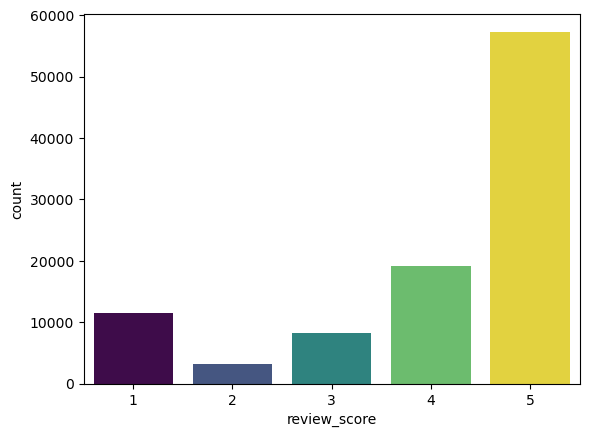

In [42]:
sns.countplot(x='review_score', data=df_order_reviews, hue='review_score', palette='viridis', legend=False)

In [43]:
df_reviews_full = df_order_reviews.merge(df_orders, on='order_id', how='left')
df_reviews_full = df_reviews_full.merge(df_customers, on='customer_id', how='left')

df_reviews_full['order_delivered_customer_date'] = pd.to_datetime(df_reviews_full['order_delivered_customer_date'])
df_reviews_full['order_estimated_delivery_date'] = pd.to_datetime(df_reviews_full['order_estimated_delivery_date'])
df_reviews_full['delivery_delay'] = (df_reviews_full['order_delivered_customer_date'] - df_reviews_full['order_estimated_delivery_date']).dt.days

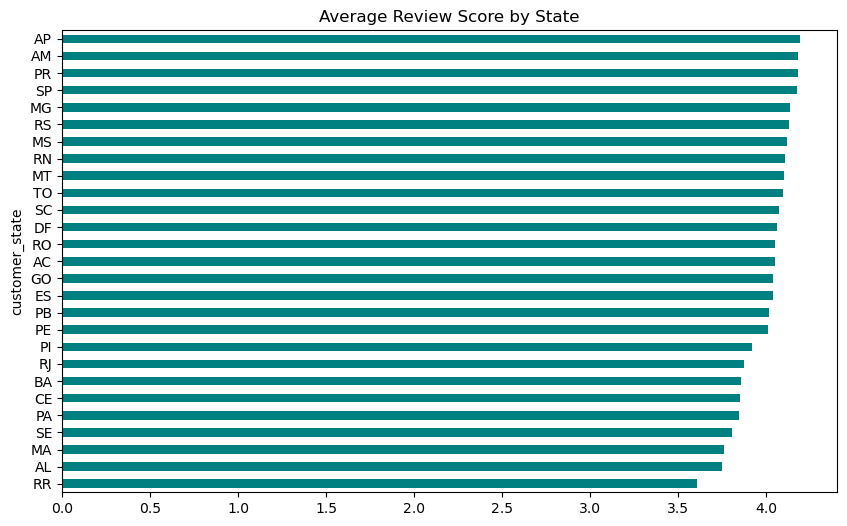

In [44]:
avg_review_by_state = df_reviews_full.groupby('customer_state')['review_score'].mean().sort_values()
avg_review_by_state.plot(kind='barh', color='teal', figsize=(10,6))
plt.title('Average Review Score by State')
plt.show()

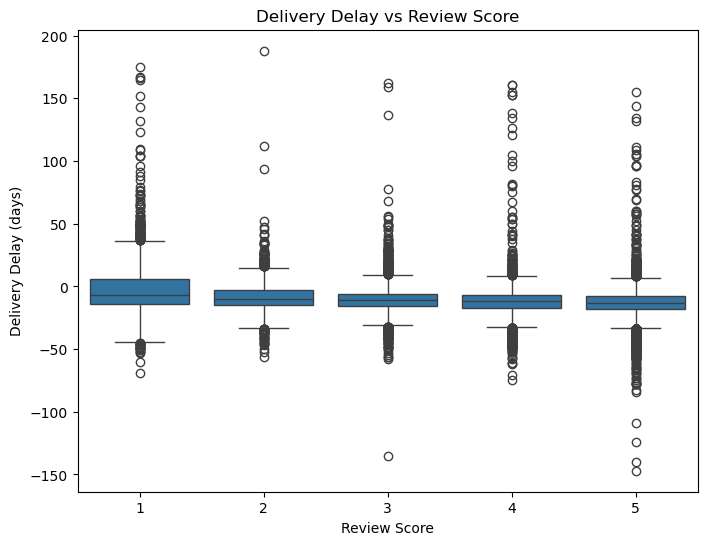

In [45]:
plt.figure(figsize=(8,6))
sns.boxplot(x='review_score', y='delivery_delay', data=df_reviews_full)
plt.title('Delivery Delay vs Review Score')
plt.xlabel('Review Score')
plt.ylabel('Delivery Delay (days)')
plt.show()

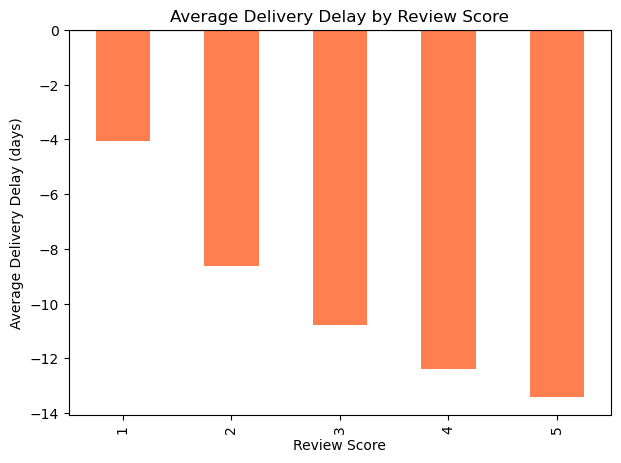

In [46]:
avg_delay_by_score = df_reviews_full.groupby('review_score')['delivery_delay'].mean()

plt.figure(figsize=(7,5))
avg_delay_by_score.plot(kind='bar', color='coral')
plt.title('Average Delivery Delay by Review Score')
plt.xlabel('Review Score')
plt.ylabel('Average Delivery Delay (days)')
plt.axhline(0, color='black', linewidth=0.8)  # reference line: 0 = on-time
plt.show()

In [47]:
df_reviews_full['is_late'] = df_reviews_full['delivery_delay'] > 0
df_reviews_full.groupby('review_score')['is_late'].mean()

review_score
1    0.301471
2    0.176452
3    0.085341
4    0.034061
5    0.018490
Name: is_late, dtype: float64

In [48]:
late_rate_by_state = df_reviews_full.groupby('customer_state')['is_late'].mean().sort_values(ascending=False)
print(late_rate_by_state)

customer_state
AL    0.200483
MA    0.163539
SE    0.143266
PI    0.132383
CE    0.131678
BA    0.115579
RJ    0.114689
RR    0.108696
PA    0.103306
ES    0.101687
PB    0.097928
TO    0.096774
MS    0.093923
PE    0.090522
RN    0.089212
SC    0.078940
GO    0.062253
RS    0.059274
MT    0.056478
DF    0.054935
MG    0.043699
SP    0.042912
PR    0.038706
AC    0.037037
AP    0.029851
RO    0.027778
AM    0.027211
Name: is_late, dtype: float64


In [49]:
print(df_reviews_full.columns.tolist())

['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_time_days', 'delivery_delay_days', 'purchase_year', 'purchase_month', 'purchase_dayofweek', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'delivery_delay', 'is_late']


In [50]:
avg_delivery_by_state = df_reviews_full.groupby('customer_state')['delivery_time_days'].mean().sort_values(ascending=False)
print(avg_delivery_by_state)

customer_state
RR    28.975610
AP    26.666667
AM    25.875862
AL    23.947236
PA    23.187433
SE    20.949102
MA    20.935754
CE    20.757837
AC    20.637500
PB    19.750487
PI    19.027542
RO    18.913223
BA    18.798521
RN    18.788584
PE    17.858491
MT    17.496599
TO    17.245421
MS    15.209859
ES    15.162791
GO    15.099847
RS    14.818385
RJ    14.791843
SC    14.425580
DF    12.532791
MG    11.523382
PR    11.517382
SP     8.287440
Name: delivery_time_days, dtype: float64


In [51]:
late_rate_by_state = df_reviews_full.groupby('customer_state')['is_late'].mean().sort_values(ascending=False)
print(late_rate_by_state)

customer_state
AL    0.200483
MA    0.163539
SE    0.143266
PI    0.132383
CE    0.131678
BA    0.115579
RJ    0.114689
RR    0.108696
PA    0.103306
ES    0.101687
PB    0.097928
TO    0.096774
MS    0.093923
PE    0.090522
RN    0.089212
SC    0.078940
GO    0.062253
RS    0.059274
MT    0.056478
DF    0.054935
MG    0.043699
SP    0.042912
PR    0.038706
AC    0.037037
AP    0.029851
RO    0.027778
AM    0.027211
Name: is_late, dtype: float64


In [52]:
avg_review_by_state = df_reviews_full.groupby('customer_state')['review_score'].mean().sort_values()

In [53]:
state_summary = pd.DataFrame({
    'avg_delivery_time': avg_delivery_by_state,
    'late_rate': late_rate_by_state,
    'avg_review_score': avg_review_by_state
}).sort_values('late_rate', ascending=False)

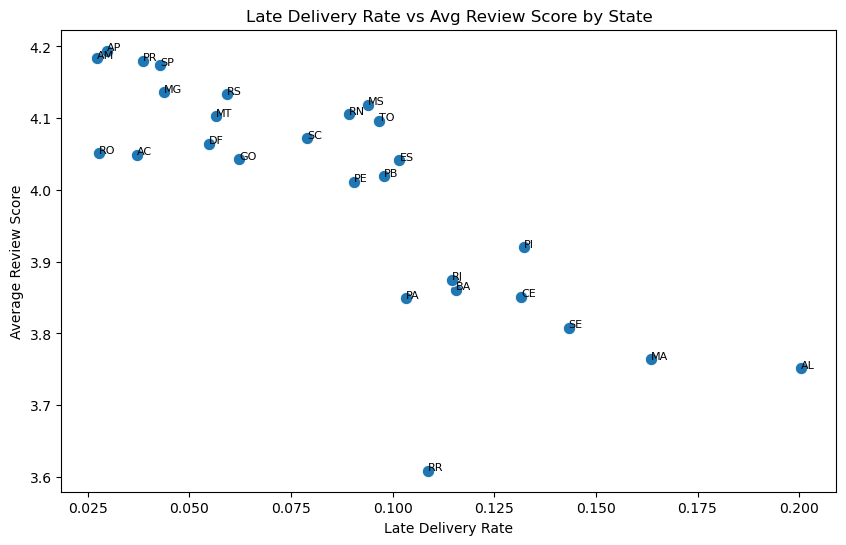

In [54]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='late_rate', y='avg_review_score', data=state_summary, s=80)
for state in state_summary.index:
    plt.text(state_summary.loc[state, 'late_rate'], state_summary.loc[state, 'avg_review_score'], state, fontsize=8)
plt.title('Late Delivery Rate vs Avg Review Score by State')
plt.xlabel('Late Delivery Rate')
plt.ylabel('Average Review Score')
plt.show()

In [55]:
pd.set_option('display.max_rows', None)
print(state_summary)

                avg_delivery_time  late_rate  avg_review_score
customer_state                                                
AL                      23.947236   0.200483          3.751208
MA                      20.935754   0.163539          3.764075
SE                      20.949102   0.143266          3.808023
PI                      19.027542   0.132383          3.920570
CE                      20.757837   0.131678          3.851016
BA                      18.798521   0.115579          3.860888
RJ                      14.791843   0.114689          3.874971
RR                      28.975610   0.108696          3.608696
PA                      23.187433   0.103306          3.849174
ES                      15.162791   0.101687          4.041667
PB                      19.750487   0.097928          4.018832
TO                      17.245421   0.096774          4.096774
MS                      15.209859   0.093923          4.118785
PE                      17.858491   0.090522          4

In [56]:
seller_orders = df_order_items.merge(df_orders, on='order_id').merge(df_order_reviews, on='order_id')

seller_perf = seller_orders.groupby('seller_id').agg(
    order_count=('order_id', 'nunique'),
    avg_review_score=('review_score', 'mean'),
    total_revenue=('price', 'sum')
).reset_index()

volume_threshold = seller_perf['order_count'].quantile(0.75)
review_threshold = 3.0

risky_sellers = seller_perf[
    (seller_perf['order_count'] >= volume_threshold) &
    (seller_perf['avg_review_score'] <= review_threshold)
].sort_values('order_count', ascending=False)

print(risky_sellers)

                             seller_id  order_count  avg_review_score  \
553   2eb70248d66e0e3ef83659f71b244378          198          2.712919   
333   1ca7077d890b907f89be8c954a02686a          114          2.198529   
2000  a49928bcdf77c55c6d6e05e09a9b4ca5           98          2.952830   
1842  972d0f9cf61b499a4812cf0bfa3ad3c4           79          2.964286   
1029  54965bbe3e4f07ae045b90b0b8541f52           74          2.938272   
491   2a1348e9addc1af5aaa619b1a3679d6b           51          3.000000   
1175  602044f2c16190c2c6e45eb35c2e21cb           49          2.932203   
463   2709af9587499e95e803a6498a5a56e9           25          2.565217   
2128  b19f3ca2ea475913750f25a5c37c8d8f           24          2.791667   

      total_revenue  
553        41307.84  
333        13191.57  
2000        8816.70  
1842        7748.79  
1029       10416.60  
491         2613.10  
1175        3851.63  
463         1180.56  
2128        6202.91  


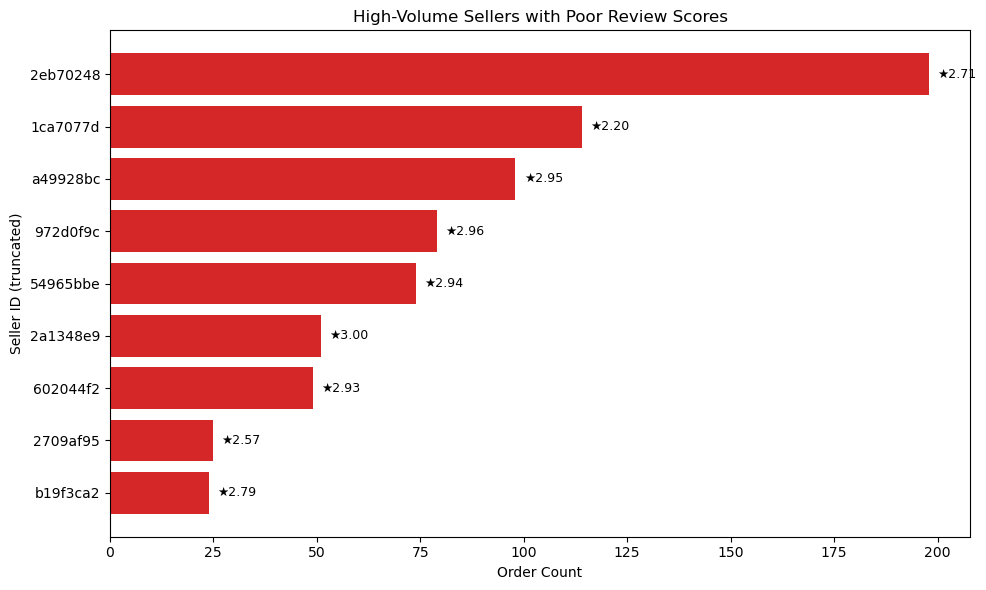

In [57]:
risky_sellers_sorted = risky_sellers.sort_values('order_count', ascending=True)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for order count
bars = ax1.barh(risky_sellers_sorted['seller_id'].str[:8], risky_sellers_sorted['order_count'], color='#d62728')
ax1.set_xlabel('Order Count')
ax1.set_ylabel('Seller ID (truncated)')
ax1.set_title('High-Volume Sellers with Poor Review Scores')

# Annotate each bar with avg review score
for bar, score in zip(bars, risky_sellers_sorted['avg_review_score']):
    ax1.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
              f'★{score:.2f}', va='center', fontsize=9, color='black')

plt.tight_layout()
plt.show()

In [58]:
risky_ids = risky_sellers['seller_id']

risky_detail = df_order_items[df_order_items['seller_id'].isin(risky_ids)]

risky_detail = risky_detail.merge(
    df_orders[['order_id', 'delivery_delay_days']],
    on='order_id', how='left'
)

risky_detail = risky_detail.merge(
    df_products[['product_id', 'product_category_name']],
    on='product_id', how='left'
)

# Add English category names
risky_detail = risky_detail.merge(
    df_category_translation[['product_category_name', 'product_category_name_english']],
    on='product_category_name', how='left'
)

delay_summary = risky_detail.groupby('seller_id').agg(
    avg_delay=('delivery_delay_days', 'mean'),
    pct_late=('delivery_delay_days', lambda x: (x > 0).mean() * 100)
).reset_index()

category_summary = risky_detail.groupby(
    ['seller_id', 'product_category_name_english']
).size().reset_index(name='count')
category_summary = category_summary.sort_values(['seller_id', 'count'], ascending=[True, False])

In [59]:
print(delay_summary)
print(category_summary)

                          seller_id  avg_delay   pct_late
0  1ca7077d890b907f89be8c954a02686a  -6.858268  13.868613
1  2709af9587499e95e803a6498a5a56e9  -4.478261  48.936170
2  2a1348e9addc1af5aaa619b1a3679d6b   0.705882  27.272727
3  2eb70248d66e0e3ef83659f71b244378 -10.121827  10.849057
4  54965bbe3e4f07ae045b90b0b8541f52  -2.395062  30.232558
5  602044f2c16190c2c6e45eb35c2e21cb  -8.127273  19.298246
6  972d0f9cf61b499a4812cf0bfa3ad3c4  -9.755814  11.363636
7  a49928bcdf77c55c6d6e05e09a9b4ca5  -4.586538  20.754717
8  b19f3ca2ea475913750f25a5c37c8d8f  -7.052632  25.000000
                           seller_id product_category_name_english  count
0   1ca7077d890b907f89be8c954a02686a                     telephony     28
1   1ca7077d890b907f89be8c954a02686a                          toys     25
2   2709af9587499e95e803a6498a5a56e9                 health_beauty     37
3   2709af9587499e95e803a6498a5a56e9                     perfumery     10
10  2a1348e9addc1af5aaa619b1a3679d6b              

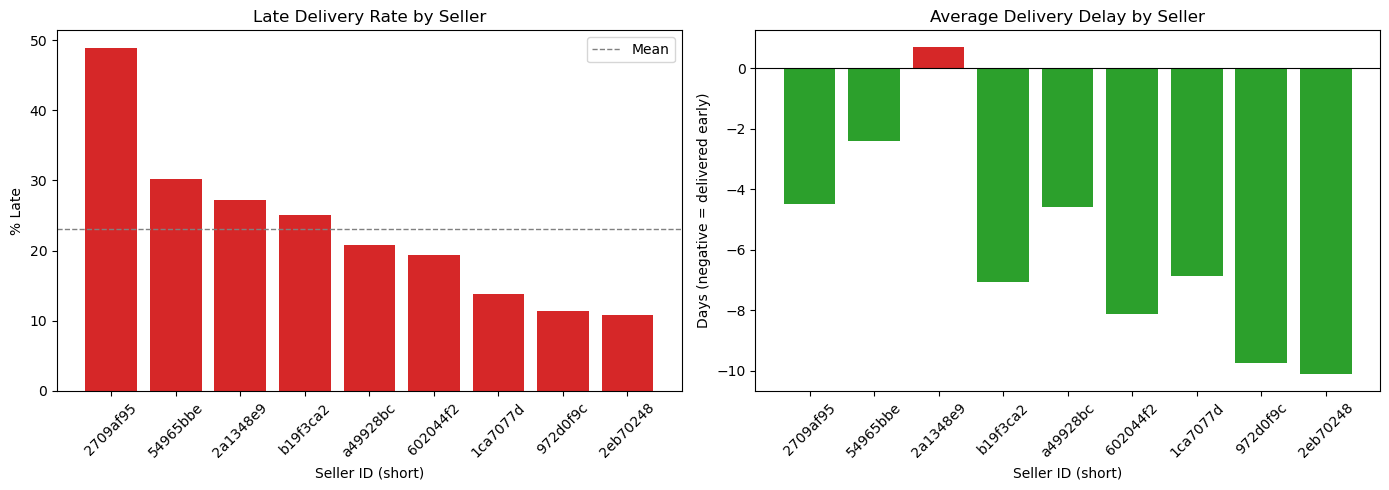

In [60]:

data = {
    'seller_id': [
        '1ca7077d890b907f89be8c954a02686a',
        '2709af9587499e95e803a6498a5a56e9',
        '2a1348e9addc1af5aaa619b1a3679d6b',
        '2eb70248d66e0e3ef83659f71b244378',
        '54965bbe3e4f07ae045b90b0b8541f52',
        '602044f2c16190c2c6e45eb35c2e21cb',
        '972d0f9cf61b499a4812cf0bfa3ad3c4',
        'a49928bcdf77c55c6d6e05e09a9b4ca5',
        'b19f3ca2ea475913750f25a5c37c8d8f',
    ],
    'avg_delay': [-6.858268, -4.478261, 0.705882, -10.121827, -2.395062,
                  -8.127273, -9.755814, -4.586538, -7.052632],
    'pct_late': [13.868613, 48.936170, 27.272727, 10.849057, 30.232558,
                 19.298246, 11.363636, 20.754717, 25.000000],
}
delay_df = pd.DataFrame(data)

# Sort by pct_late for readability
delay_df = delay_df.sort_values('pct_late', ascending=False).reset_index(drop=True)
labels = delay_df['seller_id'].str[:8]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: % Late Deliveries
axes[0].bar(labels, delay_df['pct_late'], color='#d62728')
axes[0].set_title('Late Delivery Rate by Seller')
axes[0].set_xlabel('Seller ID (short)')
axes[0].set_ylabel('% Late')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(delay_df['pct_late'].mean(), color='gray', linestyle='--', linewidth=1, label='Mean')
axes[0].legend()

colors = ['#2ca02c' if v < 0 else '#d62728' for v in delay_df['avg_delay']]
axes[1].bar(labels, delay_df['avg_delay'], color=colors)
axes[1].set_title('Average Delivery Delay by Seller')
axes[1].set_xlabel('Seller ID (short)')
axes[1].set_ylabel('Days (negative = delivered early)')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('seller_delivery_performance.png', dpi=150)
plt.show()


In [61]:
# delivery lateness flag
df_orders['is_late'] = pd.to_datetime(df_orders['order_delivered_customer_date']) > pd.to_datetime(df_orders['order_estimated_delivery_date'])

# one category per order
order_category = (
    df_order_items.merge(df_products[['product_id', 'product_category_name']], on='product_id')
    .merge(df_category_translation, on='product_category_name')
    .drop_duplicates('order_id')[['order_id', 'product_category_name_english']]
    .rename(columns={'product_category_name_english': 'category'})
)

# review score per order
reviews = df_order_reviews.drop_duplicates('order_id')[['order_id', 'review_score']]
reviews['is_negative'] = reviews['review_score'] <= 2

# combine
df = df_orders[['order_id', 'is_late']].merge(order_category, on='order_id').merge(reviews, on='order_id')

# negative rate by category: overall vs on-time only
summary = df.groupby('category')['is_negative'].mean().mul(100).round(1).rename('negative_pct_overall')
on_time_summary = df[~df['is_late']].groupby('category')['is_negative'].mean().mul(100).round(1).rename('negative_pct_on_time')

result = pd.concat([summary, on_time_summary], axis=1).sort_values('negative_pct_on_time', ascending=False)
print(result.head(15))

                                   negative_pct_overall  negative_pct_on_time
category                                                                     
security_and_services                              50.0                  50.0
fashion_male_clothing                              26.1                  24.3
fashio_female_clothing                             23.1                  21.6
office_furniture                                   22.5                  19.3
diapers_and_hygiene                                18.5                  19.2
party_supplies                                     17.9                  18.4
construction_tools_safety                          19.3                  17.5
fixed_telephony                                    18.7                  16.2
furniture_mattress_and_upholstery                  21.1                  15.2
home_confort                                       18.2                  14.6
audio                                              21.6         

In [62]:
df.to_csv('final_analyzed_data.csv', index=False)

In [63]:
import os
print(os.path.exists('final_analyzed_data.csv'))


True


In [64]:

print(os.getcwd())


C:\Users\user


In [65]:
print(df.columns.tolist())

['order_id', 'is_late', 'category', 'review_score', 'is_negative']


In [66]:
# Get order_id -> customer_id mapping from orders
order_customer = df_orders[['order_id', 'customer_id']]

# Get customer_id -> customer_state mapping from customers
customer_state = df_customers[['customer_id', 'customer_state']]

# Merge: order_id -> customer_id -> customer_state
order_customer_state = order_customer.merge(customer_state, on='customer_id', how='left')

# Now merge that onto your main df using order_id
df = df.merge(order_customer_state[['order_id', 'customer_state']], on='order_id', how='left')

# Check it worked
print(df.shape)
print(df.head())
print(df['customer_state'].isna().sum())  # should be 0 or very small

(96517, 6)
                           order_id  is_late    category  review_score  \
0  e481f51cbdc54678b7cc49136f2d6af7    False  housewares             4   
1  53cdb2fc8bc7dce0b6741e2150273451    False   perfumery             4   
2  47770eb9100c2d0c44946d9cf07ec65d    False        auto             5   
3  949d5b44dbf5de918fe9c16f97b45f8a    False    pet_shop             5   
4  ad21c59c0840e6cb83a9ceb5573f8159    False  stationery             5   

   is_negative customer_state  
0        False             SP  
1        False             BA  
2        False             GO  
3        False             RN  
4        False             SP  
0


In [67]:
# Get one seller per order (first item's seller, to avoid duplicating rows)
order_seller = df_order_items[['order_id', 'seller_id']].drop_duplicates(subset='order_id', keep='first')

# Merge onto df
df = df.merge(order_seller, on='order_id', how='left')

# Check it worked
print(df.shape)
print(df['seller_id'].isna().sum())

(96517, 7)
0


In [68]:
# Convert date columns to datetime
df_orders['order_delivered_customer_date'] = pd.to_datetime(df_orders['order_delivered_customer_date'])
df_orders['order_estimated_delivery_date'] = pd.to_datetime(df_orders['order_estimated_delivery_date'])

# Calculate delay in days (positive = late, negative = early)
df_orders['delivery_delay_days'] = (df_orders['order_delivered_customer_date'] - df_orders['order_estimated_delivery_date']).dt.days

# Merge onto df
df = df.merge(df_orders[['order_id', 'delivery_delay_days']], on='order_id', how='left')

# Check it worked
print(df.shape)
print(df['delivery_delay_days'].isna().sum())
print(df['delivery_delay_days'].describe())

(96517, 8)
2030
count    94487.000000
mean       -11.922466
std         10.114035
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay_days, dtype: float64


In [69]:
df.to_csv(folder_path + 'final_analyzed_data_v2.csv', index=False)
print(df.shape)

(96517, 8)


In [70]:
print(os.getcwd())

C:\Users\user
